# Raisin_Class_Prediction_Logistic_Regression_Project

📌 Genel Bilgiler

Amaç: Üzüm türünü tahmin etmek (sınıflandırma)

Hedef değişken (Target): Class

Kecimen

Besni

Toplam gözlem (satır): 900

Feature (özellik) sayısı: 7

Problem tipi: Binary Classification (İkili sınıflandırma)

🧬 Feature (Özellikler)

Tüm özellikler, üzüm tanelerinin görüntü işleme ile elde edilen morfolojik (şekilsel) ölçümleridir:
| Feature             | Açıklama                        |
| ------------------- | ------------------------------- |
| **Area**            | Üzüm tanesinin alanı            |
| **Perimeter**       | Çevre uzunluğu                  |
| **MajorAxisLength** | En uzun eksen uzunluğu          |
| **MinorAxisLength** | En kısa eksen uzunluğu          |
| **Eccentricity**    | Elips benzerliği (0–1 arası)    |
| **ConvexArea**      | Dışbükey (convex) alan          |
| **Extent**          | Alan / bounding box alanı oranı |


# Exploratory Data Analysis (EDA) and Visualization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (10,6)

import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
df = pd.read_excel("Raisin_Dataset.xlsx")
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246,253.291,0.820,90546,0.759,1184.040,Kecimen
1,75166,406.691,243.032,0.802,78789,0.684,1121.786,Kecimen
2,90856,442.267,266.328,0.798,93717,0.638,1208.575,Kecimen
3,45928,286.541,208.760,0.685,47336,0.700,844.162,Kecimen
4,79408,352.191,290.828,0.564,81463,0.793,1073.251,Kecimen


In [3]:
df.shape

(900, 8)

In [4]:
df.sample(5)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
367,56518,319.192,230.710,0.691,58879,0.719,916.396,Kecimen
102,57808,309.972,241.367,0.627,58954,0.710,911.857,Kecimen
731,84383,403.909,271.252,0.741,87629,0.675,1140.605,Besni
641,131847,560.421,302.641,0.842,134950,0.744,1446.145,Besni
255,41755,296.788,184.191,0.784,43362,0.691,804.559,Kecimen


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,900.000,87804.128,39002.111,25387.000,59348.000,78902.000,105028.250,235047.000
MajorAxisLength,900.000,430.930,116.035,225.630,345.443,407.804,494.187,997.292
MinorAxisLength,900.000,254.488,49.989,143.711,219.111,247.848,279.889,492.275
Eccentricity,900.000,0.782,0.090,0.349,0.742,0.799,0.843,0.962
ConvexArea,900.000,91186.090,40769.290,26139.000,61513.250,81651.000,108375.750,278217.000
Extent,900.000,0.700,0.053,0.380,0.671,0.707,0.735,0.835
Perimeter,900.000,1165.907,273.764,619.074,966.411,1119.509,1308.390,2697.753


In [7]:
df.duplicated().sum() # duplicate veri yok

np.int64(0)

In [8]:
df.isnull().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [9]:
df["Class"].value_counts() # Balanced data

Class
Kecimen    450
Besni      450
Name: count, dtype: int64

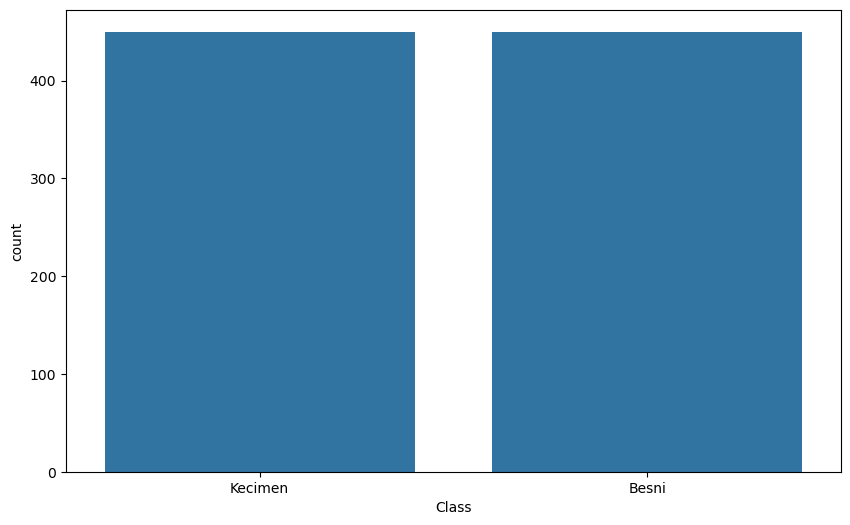

In [10]:
ax = sns.countplot(x = "Class", data = df)
plt.show()

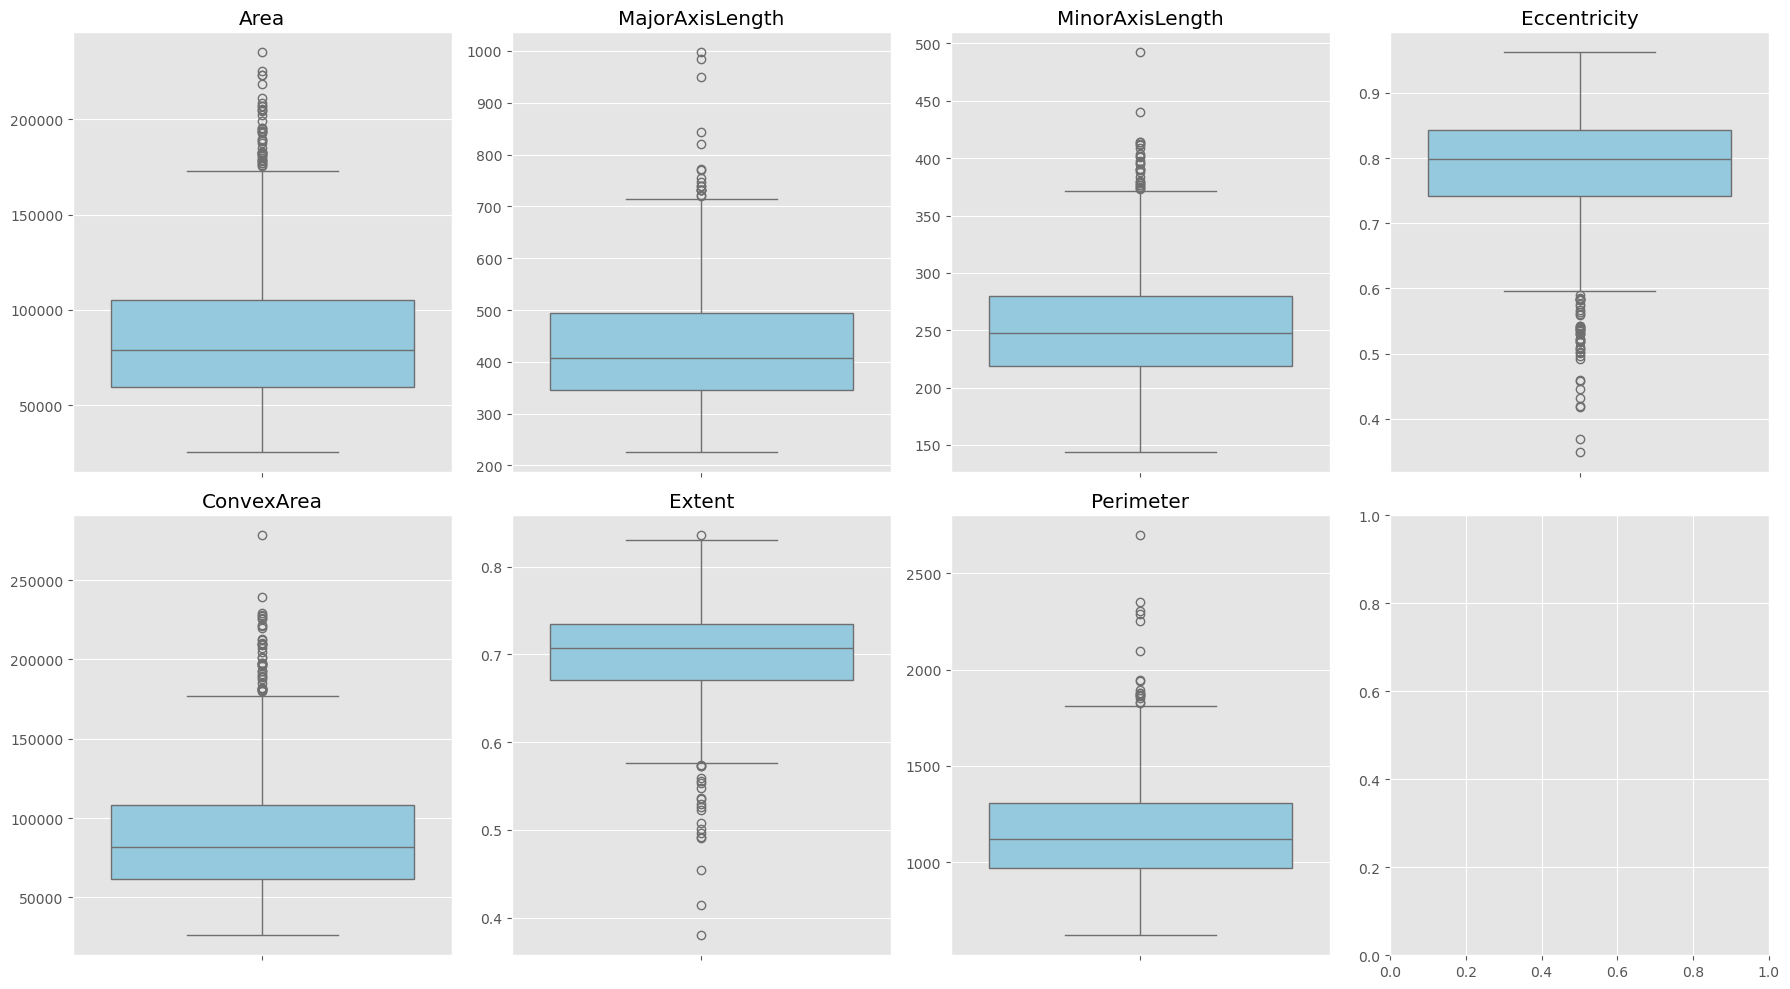

In [11]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
features = df.columns[:-1]
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

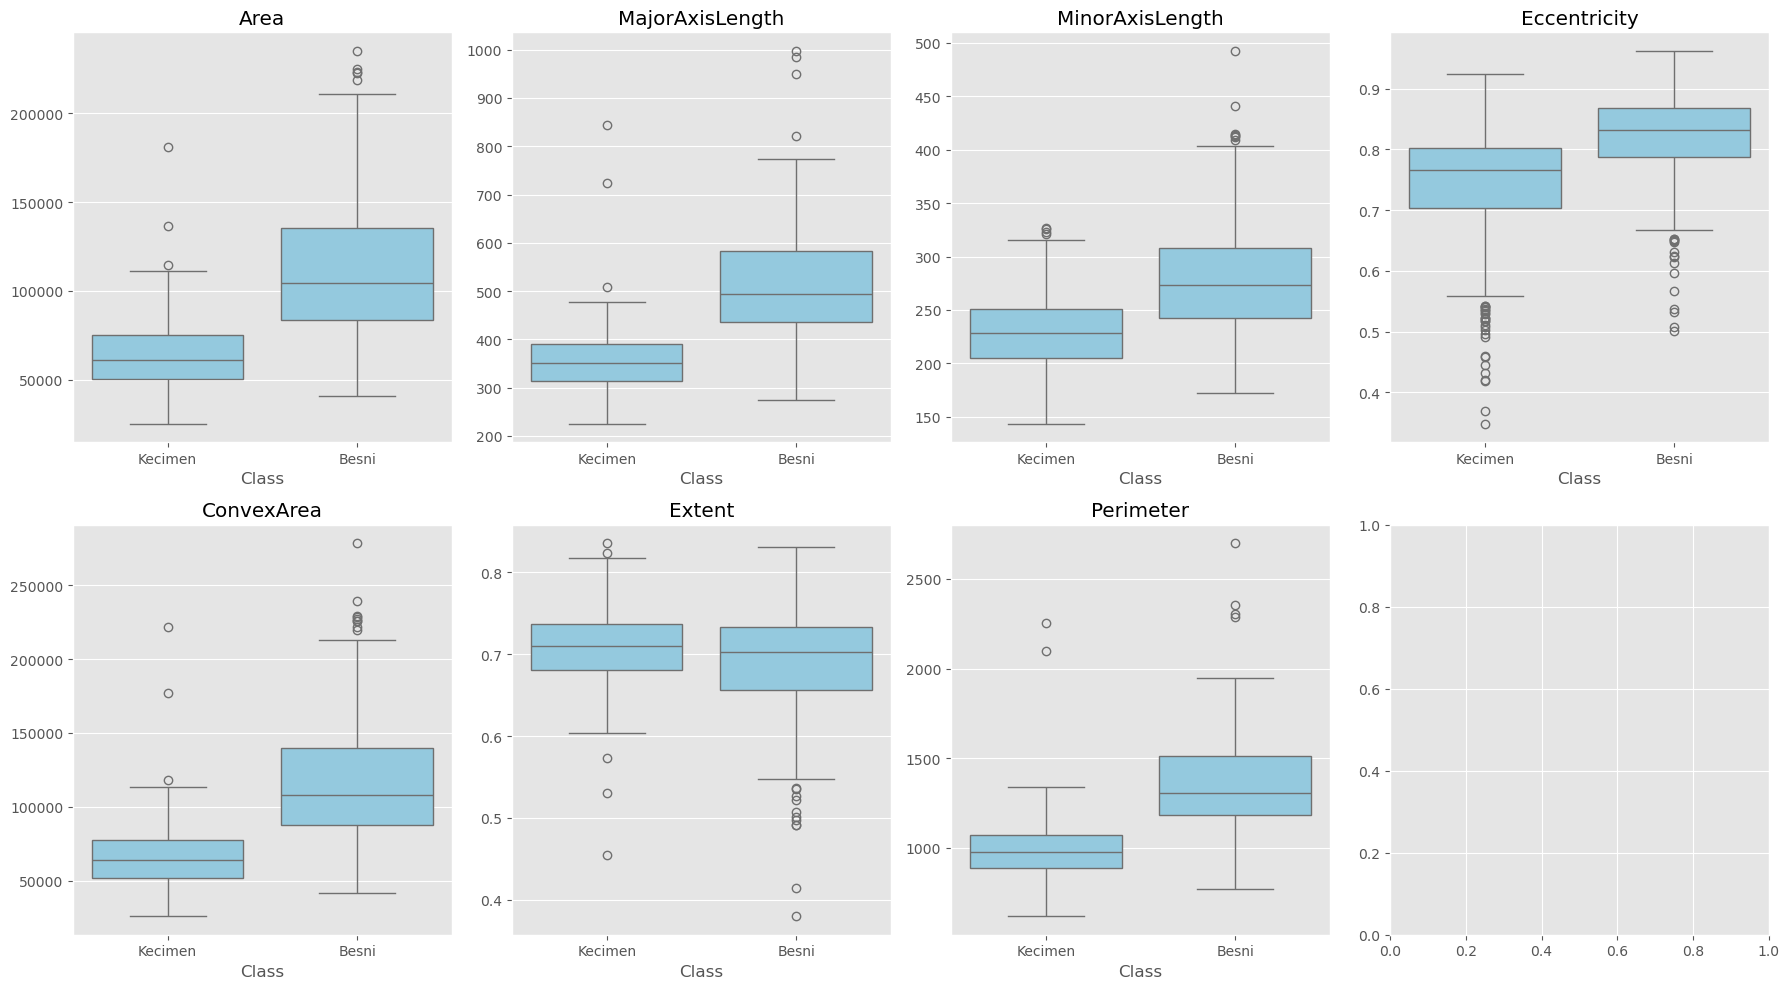

In [12]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
features = df.columns[:-1]
for i, col in enumerate(features):
    sns.boxplot(x = df['Class'], y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

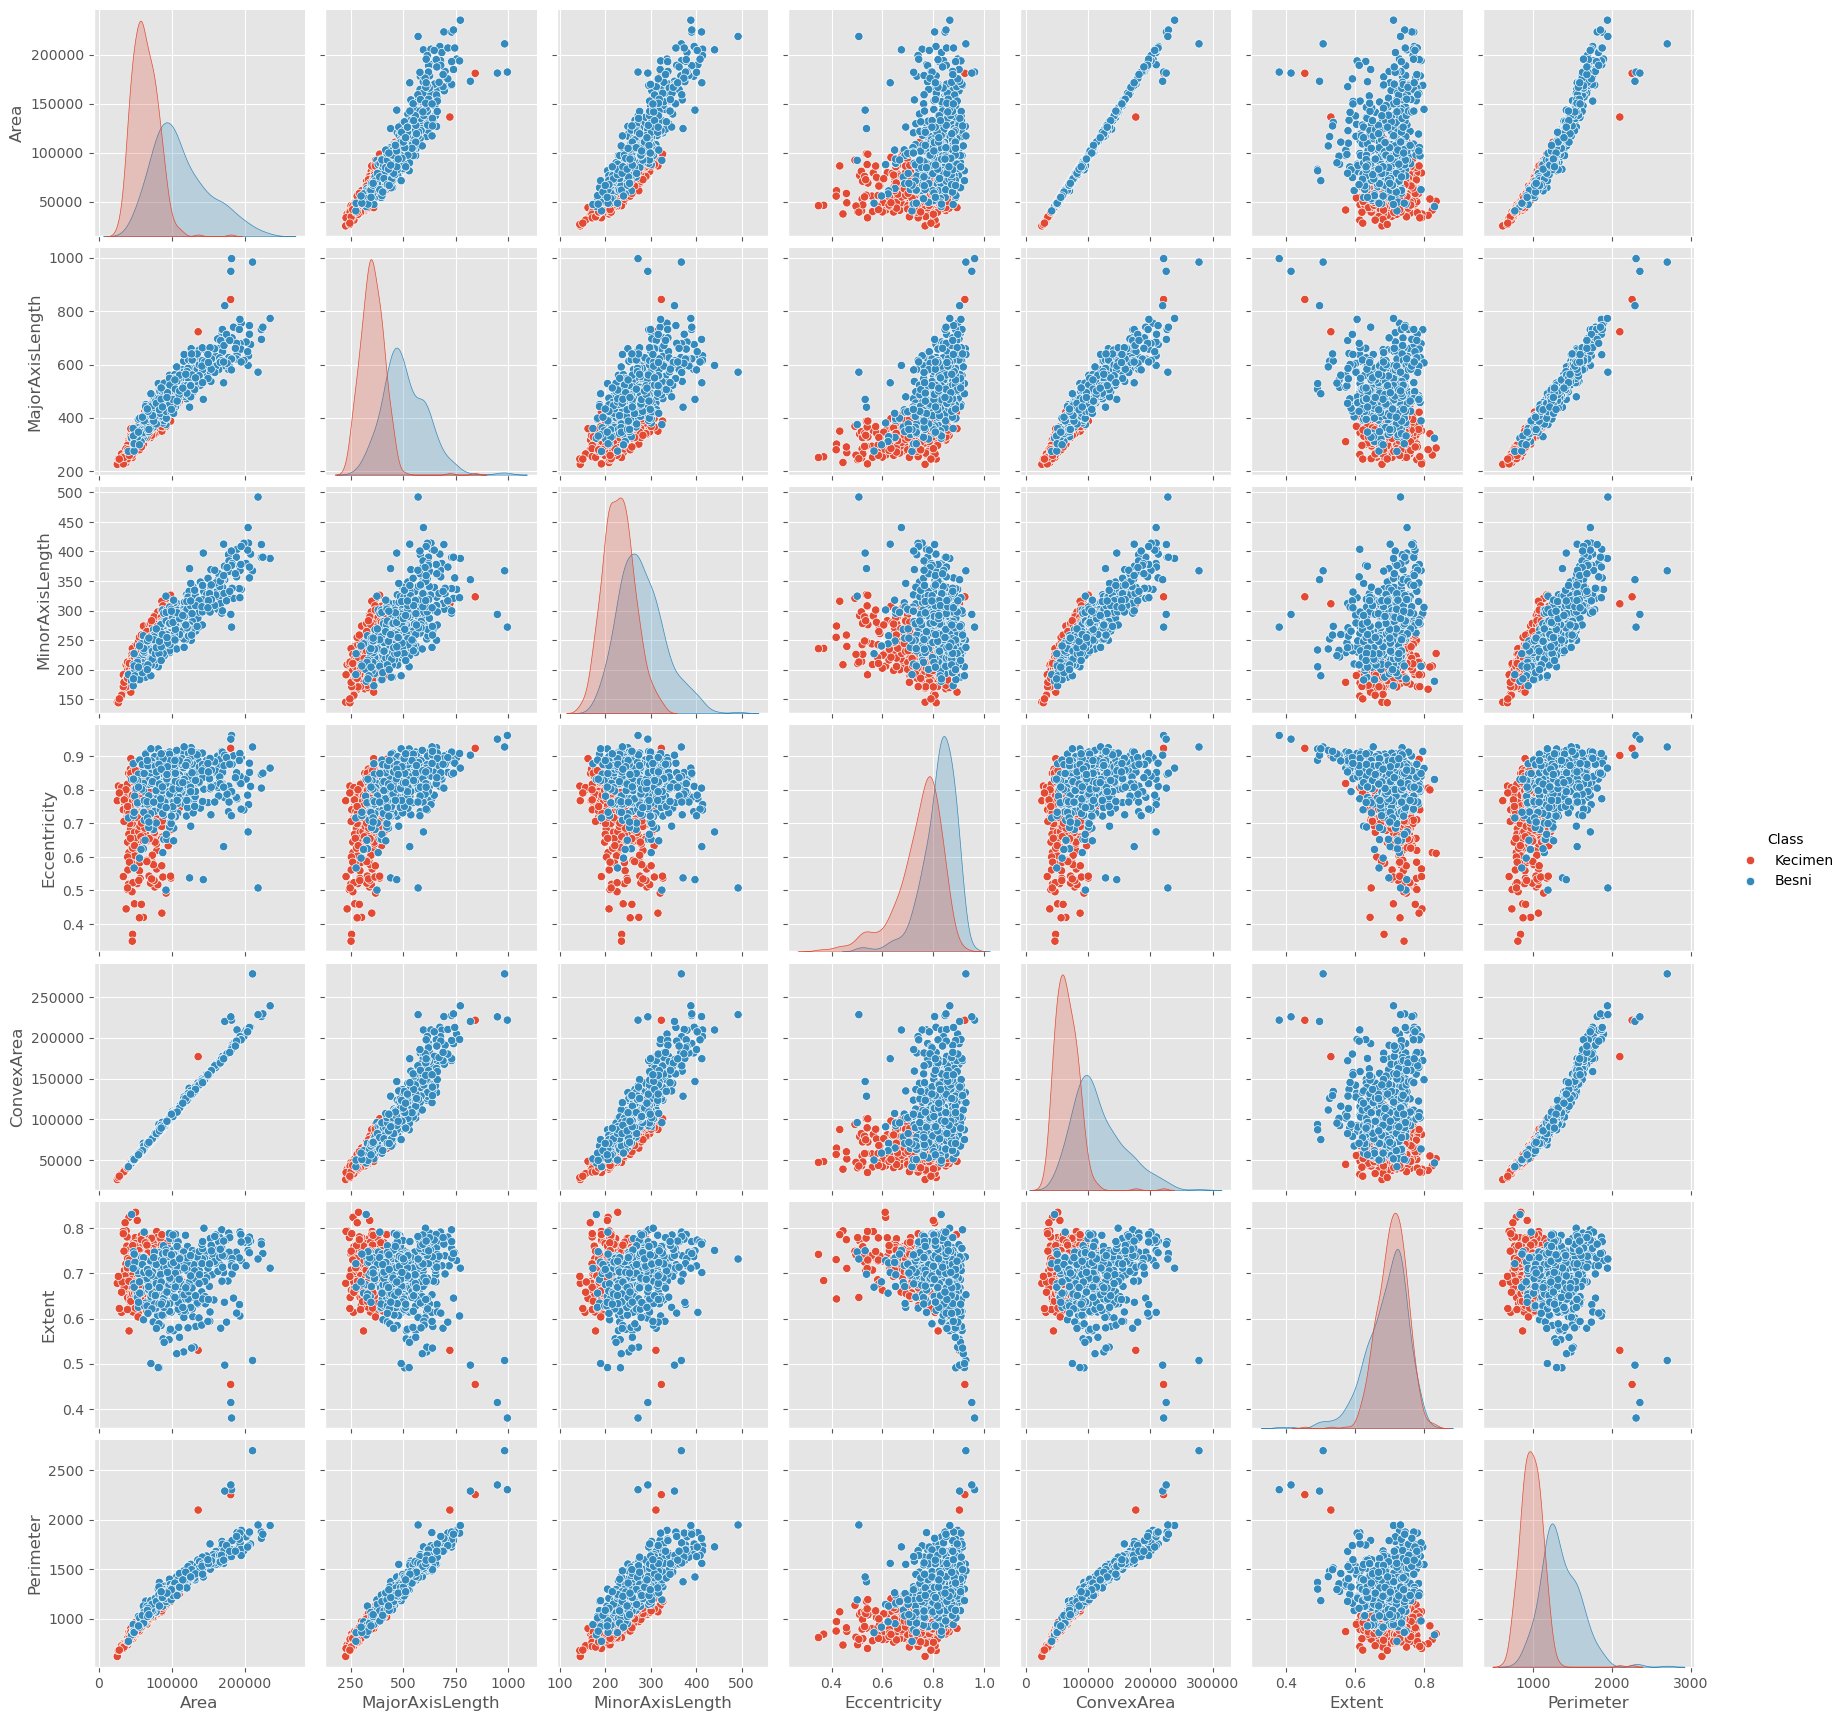

In [13]:
sns.pairplot(df, hue = "Class");

In [14]:
df["Class"] = df["Class"].map({
    "Kecimen": 0,
    "Besni": 1
})

In [15]:
df['Class']

0      0
1      0
2      0
3      0
4      0
      ..
895    1
896    1
897    1
898    1
899    1
Name: Class, Length: 900, dtype: int64

In [16]:
df['Class'].value_counts()

Class
0    450
1    450
Name: count, dtype: int64

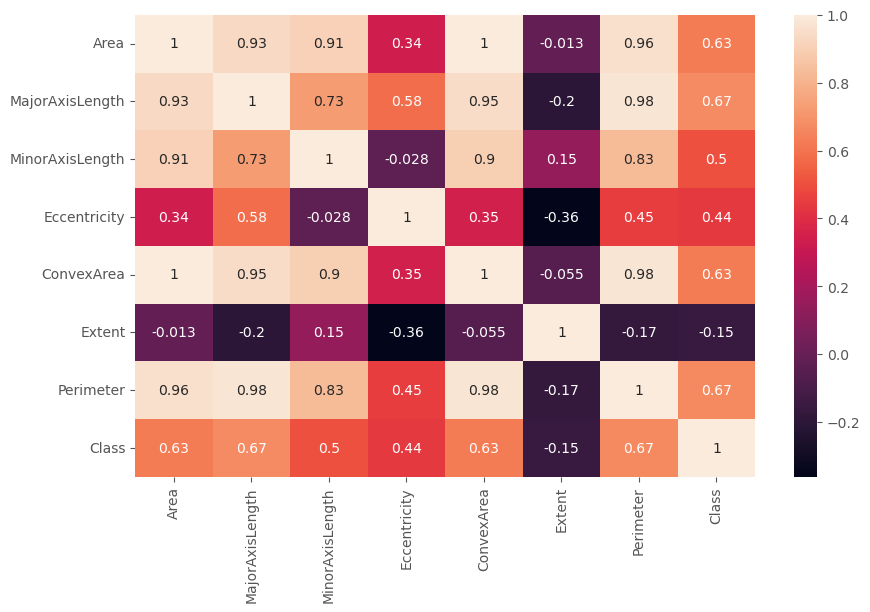

In [17]:
sns.heatmap(df.corr(), annot = True);

In [18]:
df.corr()[(df.corr()>= 0.9) & (df.corr() < 1)].any().any() # 0.90 üzeri corr sahip feature var.Multicollinearty olabilir.

np.True_

In [19]:
df.corr()[(df.corr()<= -0.9) & (df.corr() > -1)].any().any()

np.False_

In [20]:
corr_by_class = df.corr()["Class"].sort_values()[:-1]
corr_by_class

Extent            -0.155
Eccentricity       0.438
MinorAxisLength    0.503
ConvexArea         0.626
Area               0.626
Perimeter          0.666
MajorAxisLength    0.673
Name: Class, dtype: float64

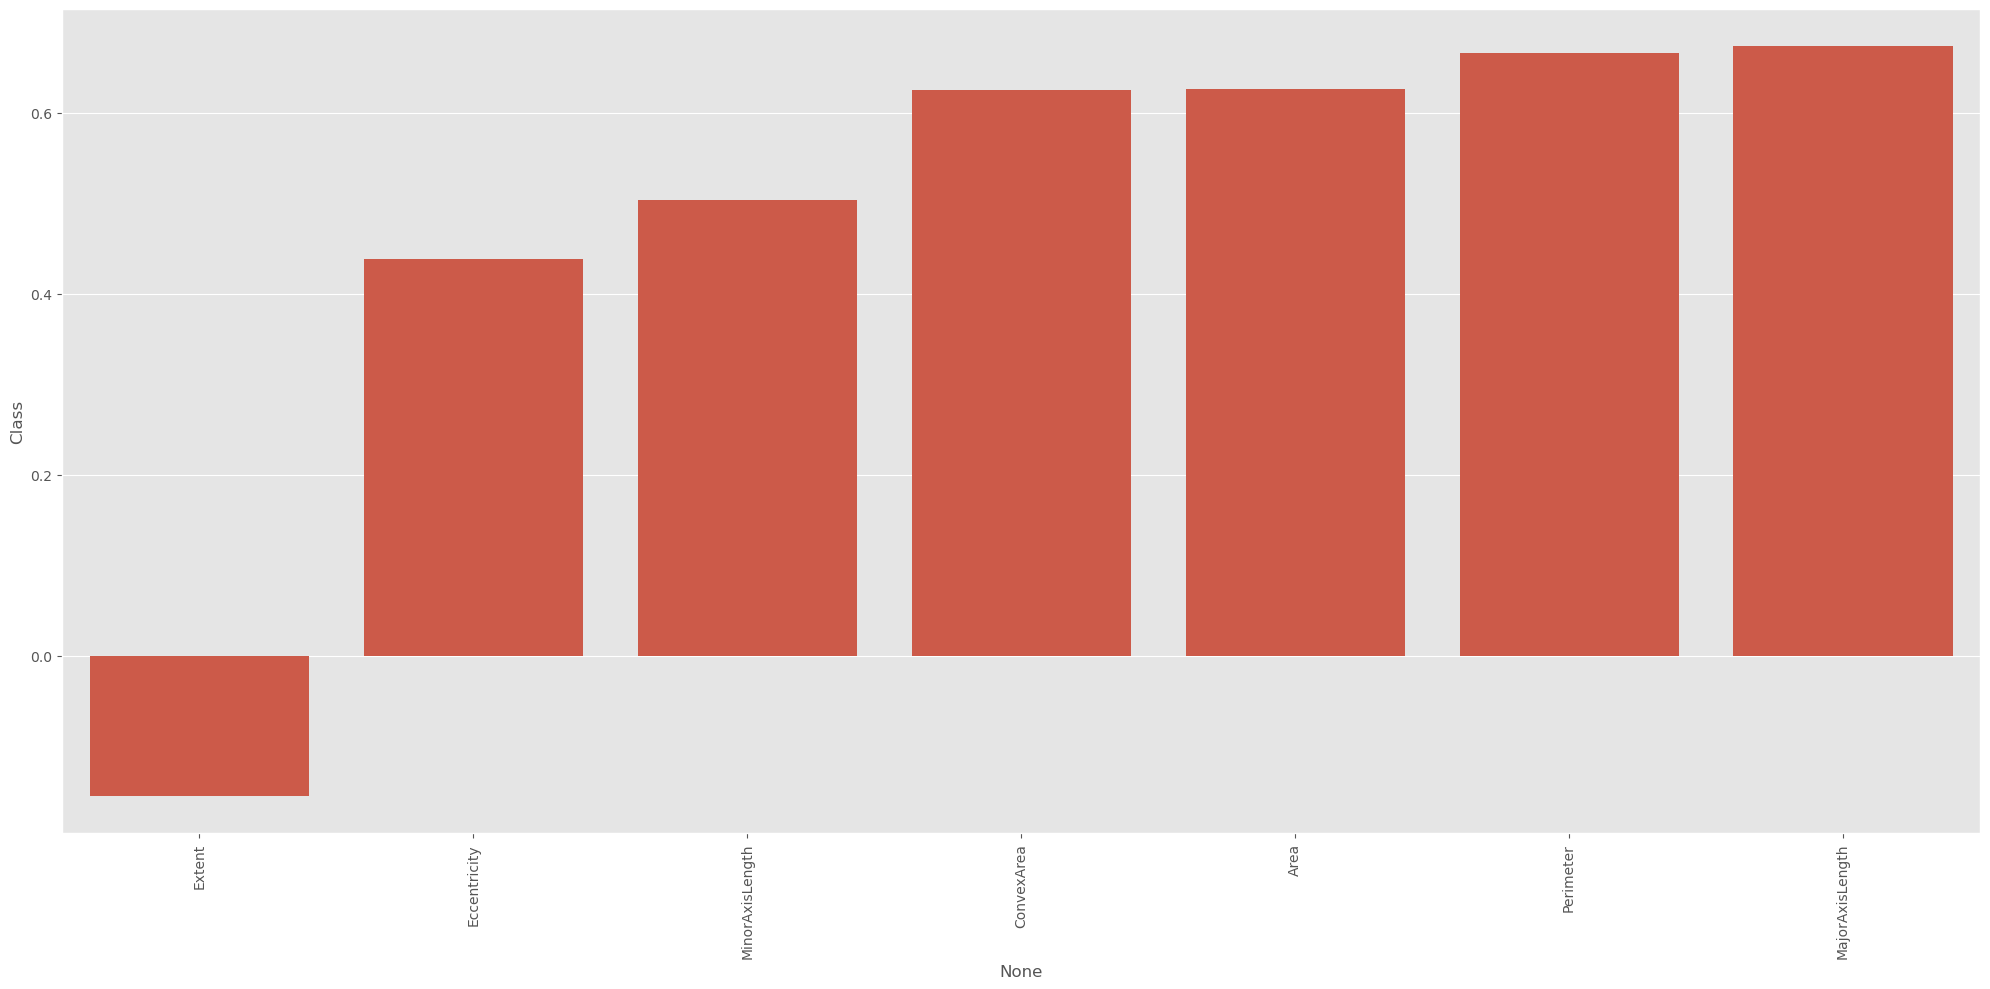

In [21]:
plt.figure(figsize = (20,10))
sns.barplot(x = corr_by_class.index, y = corr_by_class)
plt.xticks(rotation=90)
plt.tight_layout();

In [22]:
df.isnull().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

# Logistic Regression Model

## Train | Test Split and Scaling

In [23]:
X = df.drop("Class", axis = 1)
y = df["Class"] # target ve diğer featureları belirledim.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 101) # train ve test olarak veriyi ayırdım. Balansed data olduğu için stratify parametresi kullanmadım.

## Logistic Regression with Pipeline

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [26]:
operations = [("scaler", StandardScaler()), ("logistic", LogisticRegression())] # işlem adımlarımı tanımladım

In [27]:
pipe_model = Pipeline(steps = operations)

In [28]:
pipe_model.fit(X_train, y_train) # Vanilla model olarak tanımlayıp fit ettim.

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression())])

In [29]:
pipe_model["logistic"].coef_ # feature katsayılarını buldum.

array([[ 0.57997014,  0.53216308, -0.65245917,  0.11848652,  0.42703451,
        -0.09132368,  1.94732763]])

In [30]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": pipe_model.named_steps["logistic"].coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df.sort_values("Abs_Coefficient", ascending=False)

,Feature,Coefficient,Abs_Coefficient
6,Perimeter,1.947,1.947
2,MinorAxisLength,-0.652,0.652
0,Area,0.580,0.580
1,MajorAxisLength,0.532,0.532
4,ConvexArea,0.427,0.427
3,Eccentricity,0.118,0.118
5,Extent,-0.091,0.091


## X_test + y_yest + y_pred + y_pred_proba

In [31]:
y_pred = pipe_model.predict(X_test)
y_pred

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0])

In [32]:
y_pred_proba = pipe_model.predict_proba(X_test)
y_pred_proba

array([[7.56143081e-01, 2.43856919e-01],
       [2.61750469e-01, 7.38249531e-01],
       [2.30733818e-03, 9.97692662e-01],
       [2.16984737e-01, 7.83015263e-01],
       [1.13259997e-01, 8.86740003e-01],
       [9.04356742e-01, 9.56432582e-02],
       [1.09560283e-01, 8.90439717e-01],
       [8.25872687e-01, 1.74127313e-01],
       [3.84694909e-01, 6.15305091e-01],
       [4.81819846e-01, 5.18180154e-01],
       [2.89364734e-02, 9.71063527e-01],
       [4.84592579e-01, 5.15407421e-01],
       [2.77767363e-01, 7.22232637e-01],
       [3.60451072e-01, 6.39548928e-01],
       [9.15437982e-01, 8.45620177e-02],
       [7.42545368e-01, 2.57454632e-01],
       [9.71687886e-01, 2.83121137e-02],
       [9.60732417e-01, 3.92675828e-02],
       [7.94757463e-01, 2.05242537e-01],
       [6.25397899e-01, 3.74602101e-01],
       [9.35603644e-01, 6.43963563e-02],
       [5.46029662e-02, 9.45397034e-01],
       [8.81730112e-04, 9.99118270e-01],
       [6.29757318e-07, 9.99999370e-01],
       [8.853777

In [33]:
y_pred_proba_rounded = np.round(y_pred_proba, 2)
y_pred_proba_rounded

array([[0.76, 0.24],
       [0.26, 0.74],
       [0.  , 1.  ],
       [0.22, 0.78],
       [0.11, 0.89],
       [0.9 , 0.1 ],
       [0.11, 0.89],
       [0.83, 0.17],
       [0.38, 0.62],
       [0.48, 0.52],
       [0.03, 0.97],
       [0.48, 0.52],
       [0.28, 0.72],
       [0.36, 0.64],
       [0.92, 0.08],
       [0.74, 0.26],
       [0.97, 0.03],
       [0.96, 0.04],
       [0.79, 0.21],
       [0.63, 0.37],
       [0.94, 0.06],
       [0.05, 0.95],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.89, 0.11],
       [0.23, 0.77],
       [0.32, 0.68],
       [0.01, 0.99],
       [0.89, 0.11],
       [0.97, 0.03],
       [0.95, 0.05],
       [0.02, 0.98],
       [0.06, 0.94],
       [0.91, 0.09],
       [0.93, 0.07],
       [0.01, 0.99],
       [0.98, 0.02],
       [0.24, 0.76],
       [0.67, 0.33],
       [0.86, 0.14],
       [0.79, 0.21],
       [0.16, 0.84],
       [0.44, 0.56],
       [0.66, 0.34],
       [0.01, 0.99],
       [0.01, 0.99],
       [0.16, 0.84],
       [0.  ,

In [34]:
y_pred[:3] # ilk 3 ve son 3 tahmini karşılaştırdım

array([0, 1, 1])

In [35]:
y_pred[-3:]

array([1, 1, 0])

In [36]:
test_data = pd.concat([X_test, y_test], axis = 1)
test_data

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
184,81546,381.349,273.810,0.696,82807,0.712,1057.448,0
532,82161,441.796,246.810,0.829,86909,0.630,1222.158,1
501,164782,660.364,322.621,0.873,169000,0.758,1654.986,1
517,97375,468.904,268.267,0.820,100169,0.695,1244.252,1
871,105091,507.685,268.087,0.849,108296,0.700,1295.591,1
...,...,...,...,...,...,...,...,...
616,199015,615.417,413.927,0.740,201464,0.769,1687.866,1
231,52693,283.504,242.114,0.520,54860,0.738,895.745,0
620,78984,427.494,236.883,0.832,82328,0.698,1169.476,1
629,83059,440.560,243.637,0.833,88806,0.686,1238.163,1


In [37]:
test_data["predict_proba"] = y_pred_proba_rounded[:,1]
test_data # olasılıkları ekledim

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class,predict_proba
184,81546,381.349,273.810,0.696,82807,0.712,1057.448,0,0.240
532,82161,441.796,246.810,0.829,86909,0.630,1222.158,1,0.740
501,164782,660.364,322.621,0.873,169000,0.758,1654.986,1,1.000
517,97375,468.904,268.267,0.820,100169,0.695,1244.252,1,0.780
871,105091,507.685,268.087,0.849,108296,0.700,1295.591,1,0.890
...,...,...,...,...,...,...,...,...,...
616,199015,615.417,413.927,0.740,201464,0.769,1687.866,1,1.000
231,52693,283.504,242.114,0.520,54860,0.738,895.745,0,0.030
620,78984,427.494,236.883,0.832,82328,0.698,1169.476,1,0.630
629,83059,440.560,243.637,0.833,88806,0.686,1238.163,1,0.760


In [38]:
test_data["pred"] = y_pred
test_data

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class,predict_proba,pred
184,81546,381.349,273.810,0.696,82807,0.712,1057.448,0,0.240,0
532,82161,441.796,246.810,0.829,86909,0.630,1222.158,1,0.740,1
501,164782,660.364,322.621,0.873,169000,0.758,1654.986,1,1.000,1
517,97375,468.904,268.267,0.820,100169,0.695,1244.252,1,0.780,1
871,105091,507.685,268.087,0.849,108296,0.700,1295.591,1,0.890,1
...,...,...,...,...,...,...,...,...,...,...
616,199015,615.417,413.927,0.740,201464,0.769,1687.866,1,1.000,1
231,52693,283.504,242.114,0.520,54860,0.738,895.745,0,0.030,0
620,78984,427.494,236.883,0.832,82328,0.698,1169.476,1,0.630,1
629,83059,440.560,243.637,0.833,88806,0.686,1238.163,1,0.760,1


In [39]:
test_data.sample(10)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class,predict_proba,pred
100,81581,424.278,245.507,0.816,83143,0.762,1114.736,0,0.480,0
42,77055,375.250,262.812,0.714,79255,0.732,1095.283,0,0.300,0
106,48945,269.370,239.162,0.460,51456,0.711,872.289,0,0.030,0
520,155702,655.399,304.612,0.885,160709,0.697,1626.909,1,1.000,1
179,48693,306.574,204.281,0.746,50298,0.740,848.422,0,0.050,0
98,48177,305.785,202.466,0.749,49877,0.678,860.548,0,0.060,0
617,130388,511.898,326.312,0.770,132727,0.719,1393.974,1,0.930,1
762,109011,504.395,277.034,0.836,111306,0.621,1297.147,1,0.900,1
23,61251,301.508,273.660,0.420,64732,0.644,971.769,0,0.050,0
774,76624,473.966,207.737,0.899,80356,0.661,1205.819,1,0.810,1


In [40]:
test_data[test_data.Class != test_data.pred] # tamin ve target değeri farklı olanları buldum.

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class,predict_proba,pred
168,92735,436.986,271.579,0.783,94693,0.704,1183.447,0,0.620,1
408,82793,428.117,249.391,0.813,84950,0.742,1130.673,0,0.520,1
298,105020,440.390,306.105,0.719,107423,0.715,1228.366,0,0.640,1
635,70461,376.171,243.955,0.761,72819,0.728,1046.692,1,0.260,0
805,56244,398.802,182.844,0.889,58530,0.656,1008.134,1,0.370,0
693,49371,320.643,200.246,0.781,52692,0.675,921.059,1,0.110,0
341,89051,418.556,274.923,0.754,92636,0.739,1196.030,0,0.560,1
139,110616,461.145,306.899,0.746,112150,0.752,1252.875,0,0.720,1
551,68982,400.737,223.908,0.829,73278,0.729,1105.790,1,0.450,0
798,71054,364.751,249.723,0.729,72956,0.728,1027.206,1,0.200,0


## Model Performance

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [42]:
# model performanslarını inceledim. Data üzüm datası olduğu için öncelikli accuracy ve f1 score değerlerine baktım.

In [43]:
accuracy_score(y_test, y_pred)

0.9055555555555556

In [44]:
precision_score(y_test, y_pred, pos_label=1) 

0.922077922077922

In [45]:
precision_score(y_test, y_pred, pos_label=0) 

0.8932038834951457

In [46]:
recall_score(y_test, y_pred, pos_label=1)

0.8658536585365854

In [47]:
recall_score(y_test, y_pred, pos_label=0)

0.9387755102040817

In [48]:
f1_score(y_test, y_pred, pos_label=1)

0.8930817610062893

In [49]:
f1_score(y_test, y_pred, pos_label=0)

0.9154228855721394

In [50]:
pipe_model.score(X_test, y_test) # Accuracy scoru verir. Accuracy hesaplamak için farklı bir yol.

0.9055555555555556

Log loss, özellikle classification problemlerinde (binary veya multi-class) kullanılır.

Modelin doğru sınıfa verdiği olasılığı cezalandırarak değerlendirir.

Değer nasıl yorumlanır?

0’a ne kadar yakınsa o kadar iyi

Negatif olamaz

Üst sınırı yoktur

| Log Loss  | Yorum    |
| --------- | -------- |
| ~0.0      | Mükemmel |
| 0.2 – 0.4 | İyi      |
| 0.5 – 0.7 | Orta     |
| > 1       | Kötü     |


In [51]:
log_loss(y_test, y_pred_proba)

0.2634205406450705

In [52]:
confusion_matrix(y_test, y_pred)

array([[92,  6],
       [11, 71]])

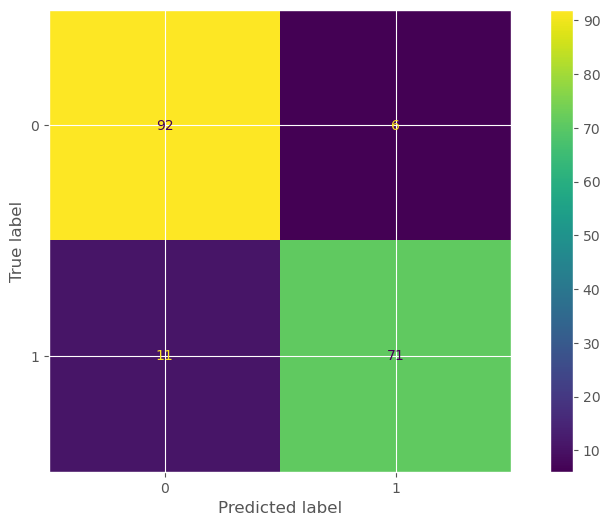

In [53]:
ConfusionMatrixDisplay.from_estimator(pipe_model, X_test, y_test)
plt.show()

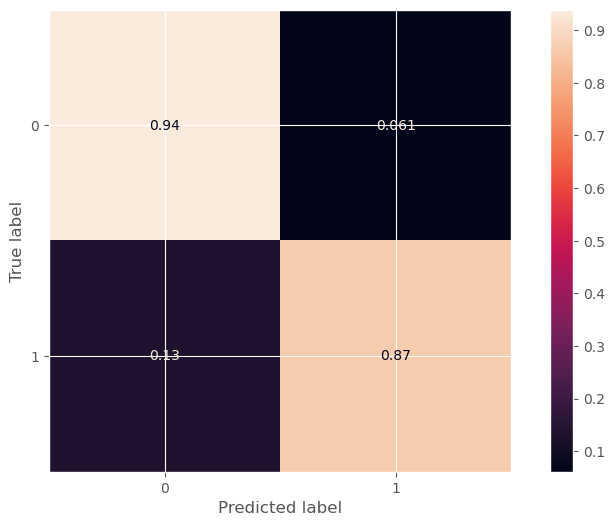

In [54]:
ConfusionMatrixDisplay.from_estimator(pipe_model, X_test, y_test, normalize = "true", cmap="rocket")
plt.show()

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92        98
           1       0.92      0.87      0.89        82

    accuracy                           0.91       180
   macro avg       0.91      0.90      0.90       180
weighted avg       0.91      0.91      0.91       180



In [56]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [57]:
eval_metric(pipe_model, X_train, y_train, X_test, y_test) # eval metric ile birlikte test ve train datasının performanslarını karşılaştırdım.

Test_Set
[[92  6]
 [11 71]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        98
           1       0.92      0.87      0.89        82

    accuracy                           0.91       180
   macro avg       0.91      0.90      0.90       180
weighted avg       0.91      0.91      0.91       180


Train_Set
[[309  43]
 [ 59 309]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       352
           1       0.88      0.84      0.86       368

    accuracy                           0.86       720
   macro avg       0.86      0.86      0.86       720
weighted avg       0.86      0.86      0.86       720



- Train datasında accuracy değeri %86 test datasında % 91 geldi, aralarında çok büyük bir fark yok overfitting yoktur diyebiliriz. Cross validate ile modelin daha iyi öğrenmesini sağlayabilirmiyiz ona bir bakalım. 

## Cross Validate

In [58]:
from sklearn.metrics import get_scorer_names
scorer_list = get_scorer_names()
scorer_list

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

In [59]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [60]:
operations = [("scaler", StandardScaler()), ("logistic", LogisticRegression())]

model = Pipeline(steps = operations)

scores = cross_validate(model, X_train, y_train, 
                        scoring = ["accuracy", "precision", "recall", "f1"],
                       cv = 10,
                       return_train_score = True)
df_scores = pd.DataFrame(scores, index = range(1,11))
df_scores

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
1,0.014,0.020,0.764,0.869,0.812,0.884,0.703,0.855,0.754,0.869
2,0.013,0.020,0.889,0.855,0.914,0.874,0.865,0.837,0.889,0.855
3,0.014,0.018,0.819,0.861,0.833,0.880,0.811,0.843,0.822,0.861
4,0.012,0.017,0.889,0.852,0.872,0.873,0.919,0.831,0.895,0.851
5,0.013,0.018,0.875,0.858,0.938,0.877,0.811,0.840,0.870,0.858
6,0.013,0.020,0.861,0.856,0.865,0.879,0.865,0.834,0.865,0.856
7,0.013,0.019,0.889,0.856,0.914,0.874,0.865,0.840,0.889,0.857
8,0.014,0.019,0.861,0.860,0.846,0.880,0.892,0.840,0.868,0.859
9,0.012,0.018,0.875,0.856,0.909,0.875,0.833,0.840,0.870,0.857
10,0.014,0.019,0.861,0.855,0.882,0.872,0.833,0.840,0.857,0.856


In [61]:
df_scores.mean()[2:]

test_accuracy     0.858
train_accuracy    0.858
test_precision    0.879
train_precision   0.877
test_recall       0.840
train_recall      0.840
test_f1           0.858
train_f1          0.858
dtype: float64

- Cross validate uygulanmış datada train ve test datasının accuracy değerleri ortalama %85 geldi. ikisi içinde vanilla modele göre bir düşüş var ancak hala overfitting yoktur. 

## GridSearchCV

- Grid search yaparak modelin en iyi çalıştığı parametreleri bulalım.

In [62]:
pipe_model.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('logistic', LogisticRegression())],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'logistic': LogisticRegression(),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'logistic__C': 1.0,
 'logistic__class_weight': None,
 'logistic__dual': False,
 'logistic__fit_intercept': True,
 'logistic__intercept_scaling': 1,
 'logistic__l1_ratio': None,
 'logistic__max_iter': 100,
 'logistic__multi_class': 'deprecated',
 'logistic__n_jobs': None,
 'logistic__penalty': 'l2',
 'logistic__random_state': None,
 'logistic__solver': 'lbfgs',
 'logistic__tol': 0.0001,
 'logistic__verbose': 0,
 'logistic__warm_start': False}

In [63]:
from sklearn.model_selection import GridSearchCV

operations = [("scaler", StandardScaler()), ("logistic", LogisticRegression())]

model = Pipeline(steps = operations)

penalty = ["l1", "l2"] 
C = np.logspace(-1, 5, 20)
class_weight = ["balanced", None] 
solver = ["lbfgs", "liblinear", "sag", "saga"] 

param_grid = {
    "logistic__penalty": penalty,
    "logistic__C": C,
    "logistic__class_weight": class_weight,
    "logistic__solver": solver
}

cv = StratifiedKFold(n_splits = 10, shuffle=True, random_state = 42)

grid_model = GridSearchCV(estimator = model,
                         param_grid = param_grid,
                         scoring = "accuracy",
                         n_jobs = -1,
                         cv = cv,
                         verbose = 1,
                         return_train_score = True)

In [64]:
grid_model.fit(X_train, y_train)

Fitting 10 folds for each of 320 candidates, totalling 3200 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logistic', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'logistic__C': array([1.00000000e-01, 2.06913808e-01, 4.28133240e-01, 8.85866790e-01,
       1.83298071e+00, 3.79269019e+00, 7.84759970e+00, 1.62377674e+01,
       3.35981829e+01, 6.95192796e+01, 1.43844989e+02, 2.97635144e+02,
       6.15848211e+02, 1.27427499e+03, 2.63665090e+03, 5.45559478e+03,
       1.12883789e+04, 2.33572147e+04, 4.83293024e+04, 1.00000000e+05]),
                         'logistic__class_weight': ['balanced', None],
                         'logistic__penalty': ['l1', 'l2'],
                         'logistic__solver': ['lbfgs', 'liblinear', 'sag',
                                              'saga']},
             return_train_score=True, scoring='accuracy', verbose=1)

In [65]:
grid_model.best_params_

{'logistic__C': np.float64(0.8858667904100825),
 'logistic__class_weight': 'balanced',
 'logistic__penalty': 'l2',
 'logistic__solver': 'lbfgs'}

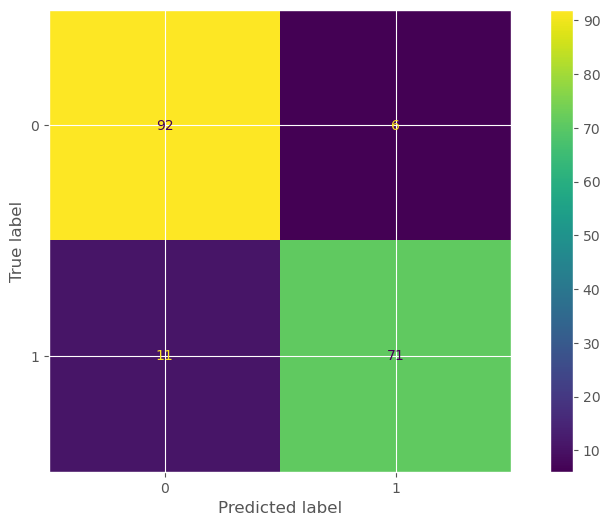

In [66]:
ConfusionMatrixDisplay.from_estimator(grid_model, X_test, y_test);

In [67]:
eval_metric(grid_model, X_train, y_train, X_test, y_test)# Grid search sonuçları

Test_Set
[[92  6]
 [11 71]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        98
           1       0.92      0.87      0.89        82

    accuracy                           0.91       180
   macro avg       0.91      0.90      0.90       180
weighted avg       0.91      0.91      0.91       180


Train_Set
[[311  41]
 [ 60 308]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       352
           1       0.88      0.84      0.86       368

    accuracy                           0.86       720
   macro avg       0.86      0.86      0.86       720
weighted avg       0.86      0.86      0.86       720



In [68]:
eval_metric(pipe_model, X_train, y_train, X_test, y_test) # Vanilla model sonuçları

Test_Set
[[92  6]
 [11 71]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        98
           1       0.92      0.87      0.89        82

    accuracy                           0.91       180
   macro avg       0.91      0.90      0.90       180
weighted avg       0.91      0.91      0.91       180


Train_Set
[[309  43]
 [ 59 309]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       352
           1       0.88      0.84      0.86       368

    accuracy                           0.86       720
   macro avg       0.86      0.86      0.86       720
weighted avg       0.86      0.86      0.86       720



- Vanilla model ile Grid model sonuçları karşılaştırıldığında birebir aynı sonuçların döndüğü görülmektedir.

## Precision-Recall Curve & ROC (Receiver Operating Curve) and AUC (Area Under Curve)

In [69]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score, auc, roc_curve, average_precision_score, precision_recall_curve

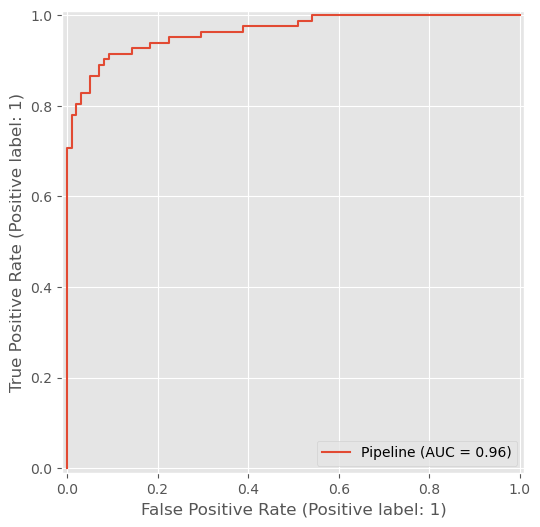

In [70]:
RocCurveDisplay.from_estimator(pipe_model, X_test, y_test)
plt.show() # Modelim 1 sınıfını 0 sınıfından % 96 başarı ile ayırabiliyor. (AUC)

In [71]:
auc_score = roc_auc_score(y_test, y_pred_proba[:,1])
auc_score

np.float64(0.9644101543056247)

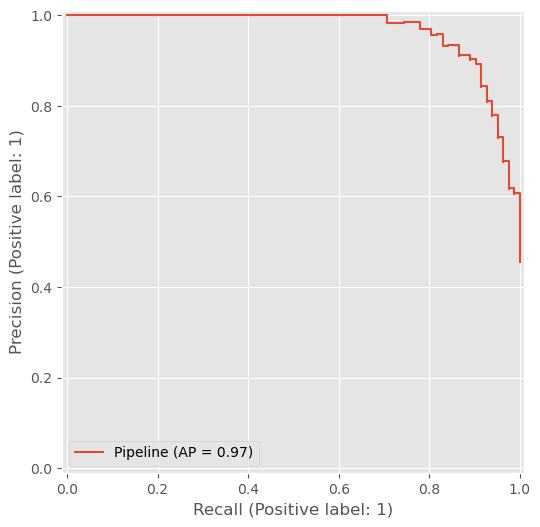

In [72]:
PrecisionRecallDisplay.from_estimator(pipe_model, X_test, y_test)
plt.show()

In [73]:
ap_score = average_precision_score(y_test, y_pred_proba[:,1]) # 1 olma olasılıkları üzerinden (predict_proba()) hesaplıyoruz
ap_score

np.float64(0.9664495887577222)

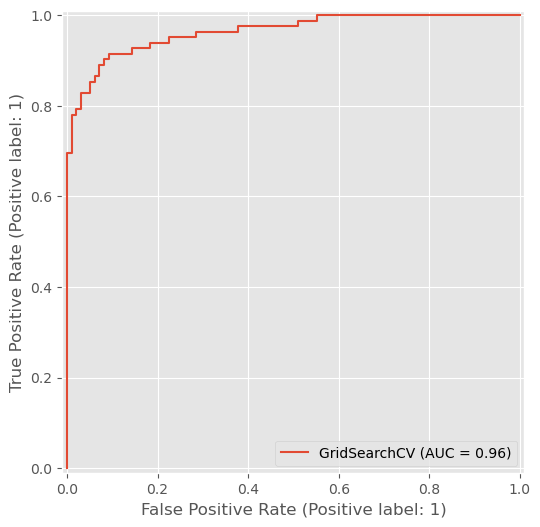

In [74]:
RocCurveDisplay.from_estimator(grid_model, X_test, y_test); # Grid Modelim 1 sınıfını 0 sınıfından % 96 başarı ile ayırabiliyor. (AUC)

In [75]:
y_pred_proba = grid_model.predict_proba(X_test)
average_precision_score(y_test, y_pred_proba[:,1])

np.float64(0.9660229591688552)

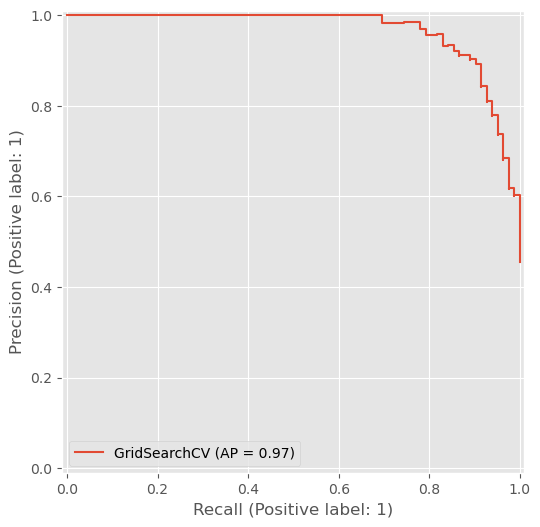

In [77]:
PrecisionRecallDisplay.from_estimator(grid_model, X_test, y_test)
plt.show()

In [76]:
y_train_pred_proba = grid_model.predict_proba(X_train)
average_precision_score(y_train, y_train_pred_proba[:,1])

np.float64(0.9194465909458891)

# Final Model

In [78]:
import pickle

In [79]:
operations = [('scaler', StandardScaler()), ('logistic', LogisticRegression())]

In [80]:
final_model = Pipeline(steps = operations)

final_model.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression())])

In [81]:
pickle.dump(final_model, open("final_pipe_model", "wb"))

# Prediction

In [82]:
new_model = pickle.load(open("final_pipe_model", "rb"))

In [83]:
df.head(1)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246,253.291,0.820,90546,0.759,1184.040,0


In [84]:
my_dict = {
    "Area": [87543, 91200, 84500, 99010, 76000, 88000, 90500, 82000],
    "MajorAxisLength": [450.3, 470.1, 440.8, 490.5, 430.2, 455.7, 465.4, 442.6],
    "MinorAxisLength": [260.7, 255.4, 270.2, 265.8, 250.3, 262.9, 258.1, 268.4],
    "Eccentricity": [0.85, 0.88, 0.82, 0.90, 0.80, 0.86, 0.87, 0.83],
    "ConvexArea": [89000, 93000, 86000, 101000, 78000, 89500, 92000, 84000],
    "Extent": [0.72, 0.70, 0.74, 0.69, 0.76, 0.71, 0.73, 0.75],
    "Perimeter": [1200.5, 1250.3, 1180.2, 1305.7, 1150.8, 1210.4, 1260.9, 1195.6],
}


sample = pd.DataFrame(my_dict)
sample

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
0,87543,450.300,260.700,0.850,89000,0.720,1200.500
1,91200,470.100,255.400,0.880,93000,0.700,1250.300
2,84500,440.800,270.200,0.820,86000,0.740,1180.200
3,99010,490.500,265.800,0.900,101000,0.690,1305.700
4,76000,430.200,250.300,0.800,78000,0.760,1150.800
5,88000,455.700,262.900,0.860,89500,0.710,1210.400
6,90500,465.400,258.100,0.870,92000,0.730,1260.900
7,82000,442.600,268.400,0.830,84000,0.750,1195.600


In [85]:
pred = new_model.predict(sample)
pred

array([1, 1, 1, 1, 1, 1, 1, 1])

In [86]:
proba = new_model.predict_proba(sample)
proba

array([[0.30174959, 0.69825041],
       [0.1643107 , 0.8356893 ],
       [0.42274249, 0.57725751],
       [0.09267672, 0.90732328],
       [0.49201069, 0.50798931],
       [0.27432066, 0.72567934],
       [0.17573117, 0.82426883],
       [0.3950449 , 0.6049551 ]])

In [87]:
sample["pred"] = pred
sample["proba"] = proba[:,1]
sample

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,pred,proba
0,87543,450.300,260.700,0.850,89000,0.720,1200.500,1,0.698
1,91200,470.100,255.400,0.880,93000,0.700,1250.300,1,0.836
2,84500,440.800,270.200,0.820,86000,0.740,1180.200,1,0.577
3,99010,490.500,265.800,0.900,101000,0.690,1305.700,1,0.907
4,76000,430.200,250.300,0.800,78000,0.760,1150.800,1,0.508
5,88000,455.700,262.900,0.860,89500,0.710,1210.400,1,0.726
6,90500,465.400,258.100,0.870,92000,0.730,1260.900,1,0.824
7,82000,442.600,268.400,0.830,84000,0.750,1195.600,1,0.605


# Conclusion

-En baştan itibaren sırasıyla EDA, Vanilla model, Cross Validate ve Gridsearch uygulaadık. Modellerin sonuçlarını incelediğimizde grid model ve vanilla modelin aynı değerleri döndürdüğünü gördük. ROC eğrisinde AUC = 0.96 çıktı. Modelim 1 sınıfını % 96 başarı ile 0 sınıfından ayırıyor. Grid model içinde aynı değerleri getirdiğini tespit ettik. O yüzden Final modeli olarak vanilla modeli seçtik ve eğittik. 